## Zadania do samodzielnego wykonania

1.

Proszę pobrać plik medicine.txt, zawierający wyniki analizy nowego leku. W dwóch pierwszych kolumnach znajduje się stężenie dwóch składników w próbce krwi, w trzeciej - informacja o tym, czy lek zadziałał. Dane nie są znormalizowane. Proszę znormalizować dane, podzielić je na zbiór uczący i testujący w proporcjach 80-20 (należy pamiętać o proporcjach klas), zaproponować wielowarstwową sieć neuronową i zbadać jej skuteczność dla różnych ilości warstw i neuronów w tych warstwach. Proszę narysować w jaki sposób sieć dokonała podziału w zbiorze dla kilku sieci (zarówno tych z dobrymi, jak i złymi wynikami) oraz jak wygląda poprawny podział zbioru. Proszę również przedstawić wyniki dla 5-8 różnych struktur sieci, wraz z oceną, która z nich najlepiej poradziła sobie z zadaniem klasyfikacji.

2.

Proszę pobrać zbiór yeast z UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Yeast). Proszę we własnym zakresie dokonać wstępnej analizy i przygotowania tego zbioru. Warto zauważyć, że liczności różnych klas wewnątrz zbioru są _bardzo_ nierówne. Proszę spróbować osiągnąć jak najlepsze wyniki i narysować dla nich macierz pomyłek (dla zbioru uczącego i testującego) oraz wyliczyć wszystkie poznane do tej pory metryki. Czy dokładność na poziomie 0.5 dla takiego zbioru jest dobra? Mogą państwo zbadać też czas wykonywania funkcji fit dla różnych konfiguracji sieci.

#### Materiały:

Dokumentacja:

* https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html

* https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html

* https://ipython.readthedocs.io/en/stable/interactive/magics.html - funkcja do uproszczonego liczenia czasu wykonywania kodu w notatniku.

# Zadanie 1


In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv('medicine.txt')

print(df.head())
print(df.info())

   Presence 1  Presence 2  Was medicine effective?
0     0.04609     6010.05                        0
1     0.02237     6119.66                        0
2     0.05054     7037.36                        0
3     0.03155     5009.20                        0
4     0.02256     6214.69                        0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Presence 1               1350 non-null   float64
 1   Presence 2               1350 non-null   float64
 2   Was medicine effective?  1350 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 31.8 KB
None


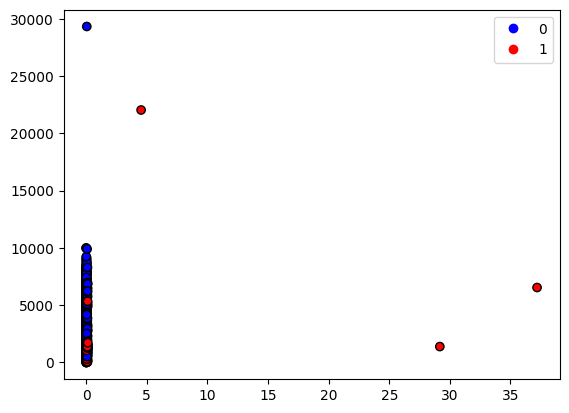

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

scatter = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df.iloc[:,2], cmap='bwr', edgecolors='k')
plt.legend(handles=scatter.legend_elements()[0], labels=['0', '1'])
#Wizualizacja zestawu danych wejciowych
plt.show()

In [3]:
#OUTLIERS

features = df.columns[:2]

# Liczymy 25 i 75 procentyle 
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Wyliczamy granice
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# tworzymy filter
condition = ~((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# uźywamy filter
df_clean = df[condition]

print(f"Rozmiar początkowy: {len(df)}, Po eliminacji: {len(df_clean)}")

df=df_clean

Rozmiar początkowy: 1350, Po eliminacji: 1285


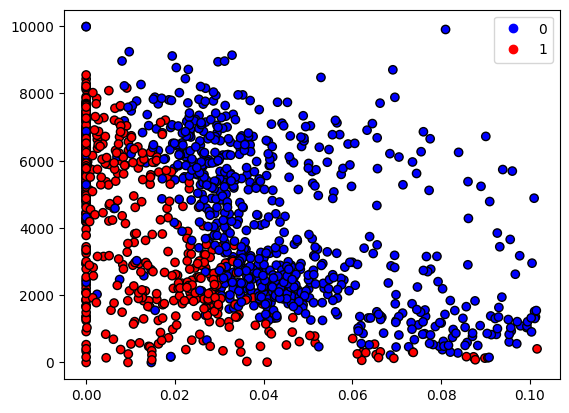

In [4]:
#Wizualizacja zestawu bez outlierów
scatter = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df.iloc[:,2], cmap='bwr', edgecolors='k')
plt.legend(handles=scatter.legend_elements()[0], labels=['0', '1'])
plt.show()

In [5]:
#SCALING PROCESS

from sklearn.preprocessing import MinMaxScaler

X = df.iloc[:, :2]
y = df.iloc[:, 2]

scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
X = pd.DataFrame(scaled_X, columns=X.columns)

X.head()

,Presence 1,Presence 2
0,0.453552,0.601584
1,0.220134,0.612555
2,0.497343,0.704414
3,0.310470,0.501402
4,0.222004,0.622067


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MLPClassifier(hidden_layer_sizes = (1, 20), max_iter=2000)

# Trenowanie modelu
model.fit(X_train, y_train)

# Ocena modelu
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))

print(f"Dokładność na zbiorze treningowym: {train_accuracy:.4f}")
print(f"Dokładność na zbiorze testowym: {test_accuracy:.4f}")

Dokładność na zbiorze treningowym: 0.9008
Dokładność na zbiorze testowym: 0.9300


C:\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


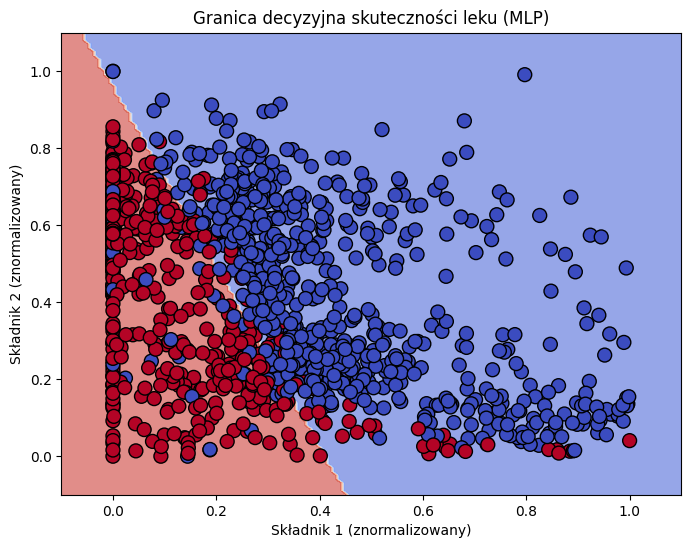

In [7]:
# Wizualizacja podziału przestrzeni dla MLP
x_min, x_max = X.iloc[:, 0].min() - 0.1, X.iloc[:, 0].max() + 0.1
y_min, y_max = X.iloc[:, 1].min() - 0.1, X.iloc[:, 1].max() + 0.1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

test_points = np.c_[xx.ravel(), yy.ravel()]

predictions = model.predict(test_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, predictions, alpha=0.6, cmap='coolwarm')

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors='k', s=100, cmap='coolwarm')

plt.title("Granica decyzyjna skuteczności leku (MLP)")
plt.xlabel("Składnik 1 (znormalizowany)")
plt.ylabel("Składnik 2 (znormalizowany)")
plt.show()

# Zadanie 2


Proszę pobrać zbiór yeast z UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Yeast). Proszę we własnym zakresie dokonać wstępnej analizy i przygotowania tego zbioru. Warto zauważyć, że liczności różnych klas wewnątrz zbioru są bardzo nierówne. Proszę spróbować osiągnąć jak najlepsze wyniki i narysować dla nich macierz pomyłek (dla zbioru uczącego i testującego) oraz wyliczyć wszystkie poznane do tej pory metryki. Czy dokładność na poziomie 0.5 dla takiego zbioru jest dobra? Mogą państwo zbadać też czas wykonywania funkcji fit dla różnych konfiguracji sieci.

In [8]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
yeast = fetch_ucirepo(id=110) 
  
# data (as pandas dataframes) 
X = yeast.data.features 
y = yeast.data.targets.values.ravel()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

Zbiór testowy


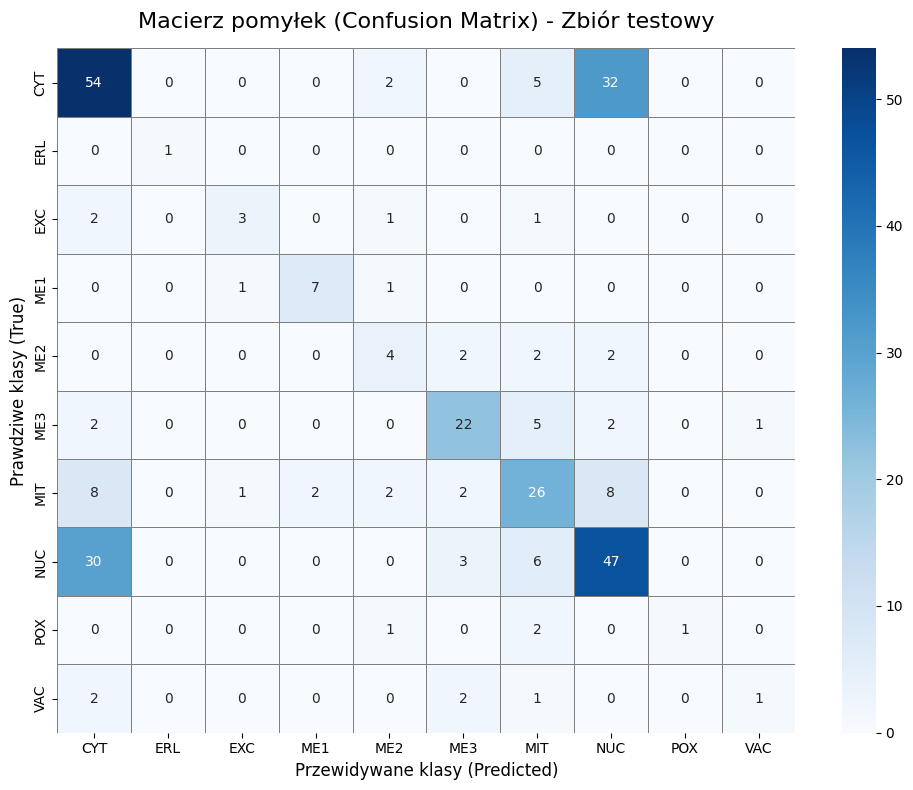


=== Wyniki dla zbioru uczącego ===
Dokładność (Accuracy): 0.5556
Precyzja (Precision):  0.5681
Czułość (Recall):      0.5556
Miara F1 (F1-score):   0.5545

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

         CYT       0.56      0.52      0.54        93
         ERL       1.00      1.00      1.00         1
         EXC       0.60      0.43      0.50         7
         ME1       0.86      0.67      0.75         9
         ME2       0.40      0.60      0.48        10
         ME3       0.72      0.72      0.72        32
         MIT       0.57      0.57      0.57        49
         NUC       0.48      0.56      0.52        86
         POX       1.00      0.25      0.40         4
         VAC       0.50      0.17      0.25         6

    accuracy                           0.56       297
   macro avg       0.67      0.55      0.57       297
weighted avg       0.57      0.56      0.55       297

Zbiór uczący


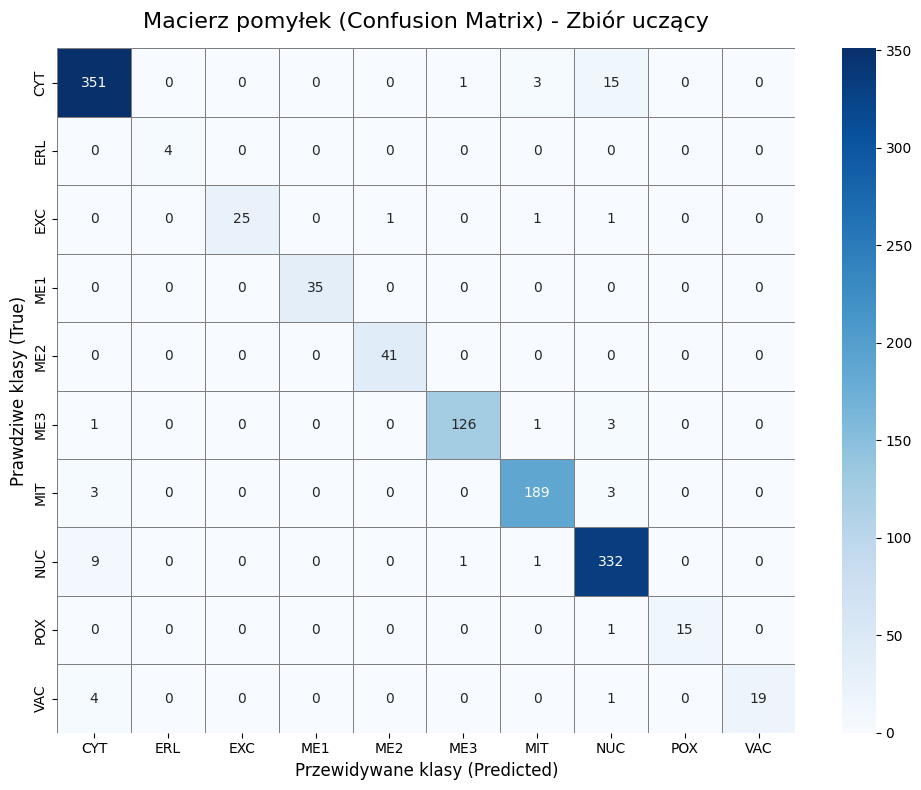

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



network = MLPClassifier(solver='adam',hidden_layer_sizes=(100, 100), max_iter = 2000, tol = 0.001, activation = 'relu')
network.fit(X_train_scaled,y_train)

print("Zbiór testowy")
predicted_labels = network.predict(X_test_scaled)
matrix = confusion_matrix(y_test, predicted_labels)


class_names = label_encoder.classes_

plt.figure(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')

plt.title('Macierz pomyłek (Confusion Matrix) - Zbiór testowy', fontsize=16, pad=15)
plt.xlabel('Przewidywane klasy (Predicted)', fontsize=12)
plt.ylabel('Prawdziwe klasy (True)', fontsize=12)

plt.tight_layout()
plt.show()





print("Zbiór uczący")
predicted_labels = network.predict(X_train_scaled)
matrix = confusion_matrix(y_train, predicted_labels) 

class_names = label_encoder.classes_

plt.figure(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.title('Macierz pomyłek (Confusion Matrix) - Zbiór uczący', fontsize=16, pad=15)
plt.xlabel('Przewidywane klasy (Predicted)', fontsize=12)
plt.ylabel('Prawdziwe klasy (True)', fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

predicted_labels_test = network.predict(X_test_scaled)

print("\n=== Wyniki dla zbioru uczącego ===")
accuracy = accuracy_score(y_test, predicted_labels_test)
precision = precision_score(y_test, predicted_labels_test, average='weighted', zero_division=0)
recall = recall_score(y_test, predicted_labels_test, average='weighted', zero_division=0)
f1 = f1_score(y_test, predicted_labels_test, average='weighted', zero_division=0)

print(f"Dokładność (Accuracy): {accuracy:.4f}")
print(f"Precyzja (Precision):  {precision:.4f}")
print(f"Czułość (Recall):      {recall:.4f}")
print(f"Miara F1 (F1-score):   {f1:.4f}\n")

print("Szczegółowy raport klasyfikacji:")
print(classification_report(y_test, predicted_labels_test, target_names=class_names, zero_division=0))


=== Wyniki dla zbioru testowego ===
Dokładność (Accuracy): 0.5556
Precyzja (Precision):  0.5681
Czułość (Recall):      0.5556
Miara F1 (F1-score):   0.5545

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

         CYT       0.56      0.52      0.54        93
         ERL       1.00      1.00      1.00         1
         EXC       0.60      0.43      0.50         7
         ME1       0.86      0.67      0.75         9
         ME2       0.40      0.60      0.48        10
         ME3       0.72      0.72      0.72        32
         MIT       0.57      0.57      0.57        49
         NUC       0.48      0.56      0.52        86
         POX       1.00      0.25      0.40         4
         VAC       0.50      0.17      0.25         6

    accuracy                           0.56       297
   macro avg       0.67      0.55      0.57       297
weighted avg       0.57      0.56      0.55       297



In [23]:
predicted_labels_train = network.predict(X_train_scaled)

print("\n=== Wyniki dla zbioru uczącego ===")
accuracy = accuracy_score(y_train, predicted_labels_train)
precision = precision_score(y_train, predicted_labels_train, average='weighted', zero_division=0)
recall = recall_score(y_train, predicted_labels_train, average='weighted', zero_division=0)
f1 = f1_score(y_train, predicted_labels_train, average='weighted', zero_division=0)

print(f"Dokładność (Accuracy): {accuracy:.4f}")
print(f"Precyzja (Precision):  {precision:.4f}")
print(f"Czułość (Recall):      {recall:.4f}")
print(f"Miara F1 (F1-score):   {f1:.4f}\n")

print("Szczegółowy raport klasyfikacji:")
print(classification_report(y_train, predicted_labels_train, target_names=class_names, zero_division=0))


=== Wyniki dla zbioru uczącego ===
Dokładność (Accuracy): 0.9579
Precyzja (Precision):  0.9585
Czułość (Recall):      0.9579
Miara F1 (F1-score):   0.9578

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

         CYT       0.95      0.95      0.95       370
         ERL       1.00      1.00      1.00         4
         EXC       1.00      0.89      0.94        28
         ME1       1.00      1.00      1.00        35
         ME2       0.98      1.00      0.99        41
         ME3       0.98      0.96      0.97       131
         MIT       0.97      0.97      0.97       195
         NUC       0.93      0.97      0.95       343
         POX       1.00      0.94      0.97        16
         VAC       1.00      0.79      0.88        24

    accuracy                           0.96      1187
   macro avg       0.98      0.95      0.96      1187
weighted avg       0.96      0.96      0.96      1187



Rozpoczęcie pomiaru czasu dla różnych architektur...

Architektura (10)            - Czas: 0.29 sekund
Architektura (50)            - Czas: 0.34 sekund
Architektura (100)           - Czas: 0.54 sekund
Architektura (50, 50)        - Czas: 1.90 sekund
Architektura (100, 100)      - Czas: 5.46 sekund
Architektura (100, 50, 25)   - Czas: 4.35 sekund


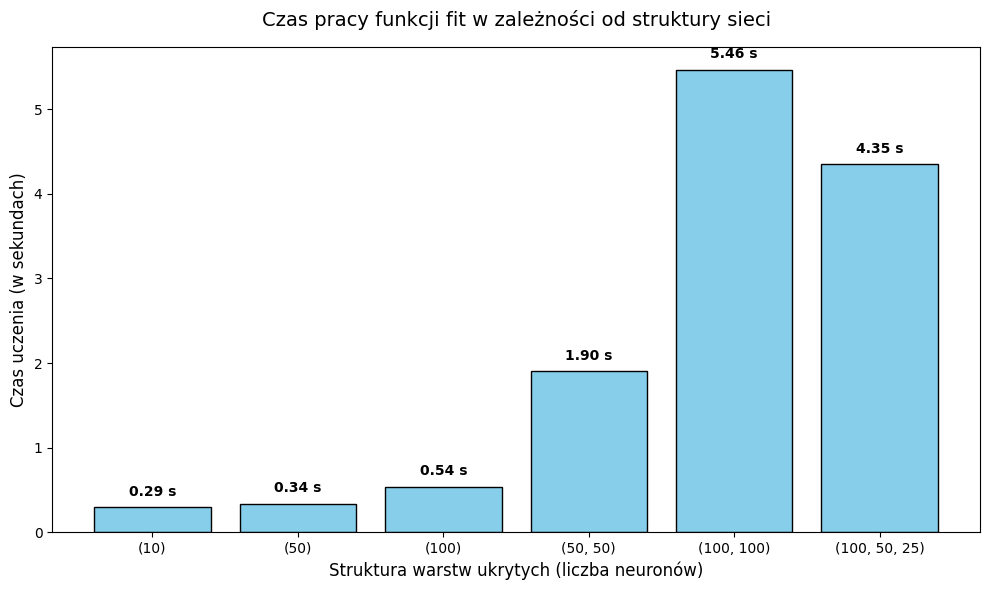

In [25]:
import time
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

architectures = [
    (10,),             
    (50,),             
    (100,),            
    (50, 50),          
    (100, 100),        
    (100, 50, 25)      
]

arch_labels = []
fit_times = []

print("Rozpoczęcie pomiaru czasu dla różnych architektur...\n")

for arch in architectures:
    network = MLPClassifier(
        solver='adam',
        hidden_layer_sizes=arch,
        max_iter=2000,
        tol=0.001,
        activation='relu',
        random_state=42 
    )
    
    arch_label = str(arch).replace(',)', ')')
    arch_labels.append(arch_label)
    
    start_time = time.time()
    
    network.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    
    elapsed_time = end_time - start_time
    fit_times.append(elapsed_time)
    
    print(f"Architektura {arch_label:15s} - Czas: {elapsed_time:.2f} sekund")

plt.figure(figsize=(10, 6))

bars = plt.bar(arch_labels, fit_times, color='skyblue', edgecolor='black')

plt.title('Czas pracy funkcji fit w zależności od struktury sieci', fontsize=14, pad=15)
plt.xlabel('Struktura warstw ukrytych (liczba neuronów)', fontsize=12)
plt.ylabel('Czas uczenia (w sekundach)', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f} s", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()